# Análisis Global de Clima y Energía 2020–2024
## Paso 4: Análisis de correlaciones, regresión e insights finales

**Autor:** Miguel Sierra  
**Objetivo:** Profundizar en la única relación estadísticamente significativa
del dataset (CO₂ vs consumo energético), construir un modelo de regresión
lineal simple, evaluar su calidad y documentar los hallazgos finales del proyecto.

**Nota metodológica:** El dataset utilizado es de naturaleza sintética,
generado para práctica de análisis de datos. Las técnicas aplicadas son
válidas y replicables sobre datos reales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/dataset_limpio.csv", parse_dates=["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

regiones = {
    "Germany":"Europa","France":"Europa","United Kingdom":"Europa",
    "Italy":"Europa","Spain":"Europa","Sweden":"Europa",
    "Norway":"Europa","Netherlands":"Europa","Poland":"Europa","Turkey":"Europa",
    "United States":"América","Canada":"América","Mexico":"América","Brazil":"América",
    "China":"Asia-Pacífico","India":"Asia-Pacífico","Japan":"Asia-Pacífico",
    "Indonesia":"Asia-Pacífico","Australia":"Asia-Pacífico",
    "South Africa":"África"
}
df["region"] = df["country"].map(regiones)

print("✅ Librerías y datos cargados correctamente")
print(f"   Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Librerías y datos cargados correctamente
   Dataset: 36,540 filas × 13 columnas


In [2]:
r, p_valor = stats.pearsonr(df["co2_emission"], df["energy_consumption"])

print("=" * 55)
print("TEST DE CORRELACIÓN DE PEARSON")
print("CO₂ vs Consumo energético")
print("=" * 55)
print(f"\n  Coeficiente r  : {r:.4f}")
print(f"  R²             : {r**2:.4f}  ({r**2*100:.2f}% de varianza explicada)")
print(f"  p-valor        : {p_valor:.2e}")
print(f"  n registros    : {len(df):,}")
print(f"\n  Interpretación :")

if p_valor < 0.05:
    print(f"  ✅ Correlación estadísticamente significativa (p < 0.05)")
else:
    print(f"  ❌ No significativa (p >= 0.05)")

if abs(r) < 0.1:
    fuerza = "despreciable"
elif abs(r) < 0.3:
    fuerza = "débil"
elif abs(r) < 0.5:
    fuerza = "moderada"
elif abs(r) < 0.7:
    fuerza = "fuerte"
else:
    fuerza = "muy fuerte"

print(f"  Fuerza         : {fuerza} ({'positiva' if r > 0 else 'negativa'})")

TEST DE CORRELACIÓN DE PEARSON
CO₂ vs Consumo energético

  Coeficiente r  : 0.1718
  R²             : 0.0295  (2.95% de varianza explicada)
  p-valor        : 6.33e-240
  n registros    : 36,540

  Interpretación :
  ✅ Correlación estadísticamente significativa (p < 0.05)
  Fuerza         : débil (positiva)


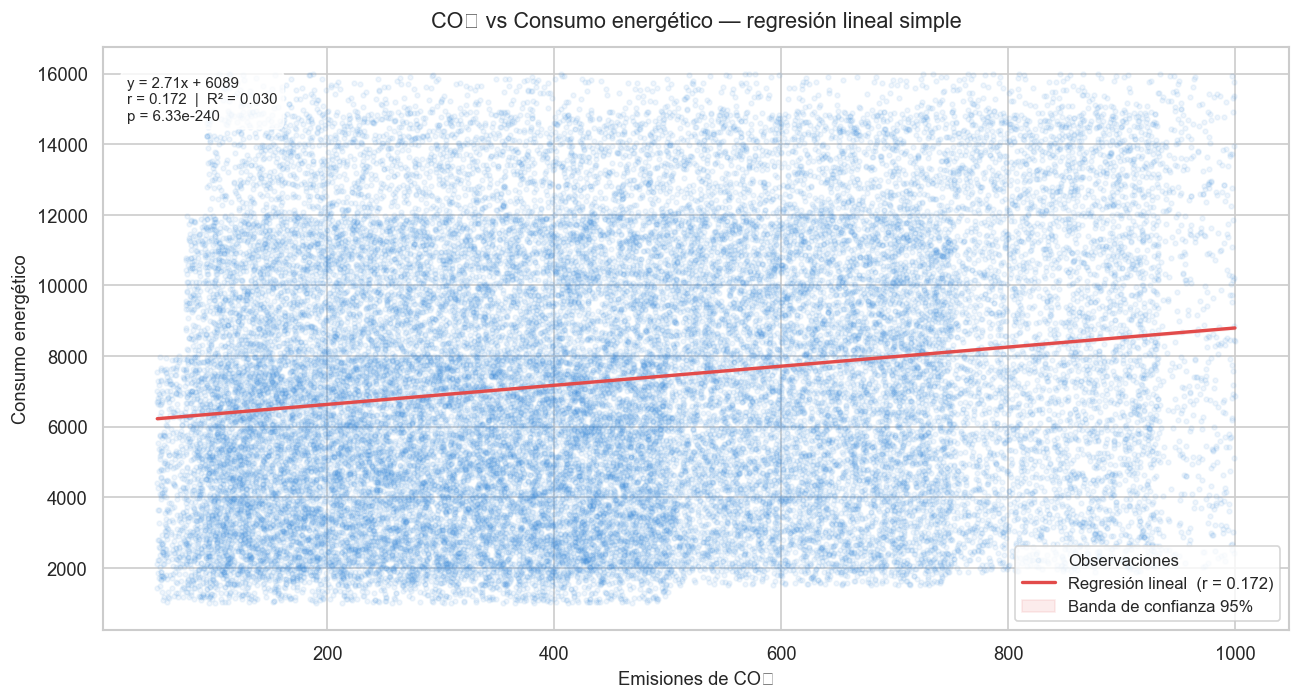

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(df["co2_emission"], df["energy_consumption"],
           alpha=0.08, s=8, color="#378ADD", label="Observaciones")

m, b, r_val, p_val, se = stats.linregress(df["co2_emission"],
                                           df["energy_consumption"])
x_line = np.linspace(df["co2_emission"].min(), df["co2_emission"].max(), 300)
y_line = m * x_line + b
y_upper = y_line + 1.96 * se * np.sqrt(len(df))
y_lower = y_line - 1.96 * se * np.sqrt(len(df))

ax.plot(x_line, y_line, color="#E24B4A", linewidth=2,
        label=f"Regresión lineal  (r = {r_val:.3f})")
ax.fill_between(x_line, y_lower, y_upper,
                alpha=0.1, color="#E24B4A", label="Banda de confianza 95%")

ax.set_xlabel("Emisiones de CO₂", fontsize=11)
ax.set_ylabel("Consumo energético", fontsize=11)
ax.set_title("CO₂ vs Consumo energético — regresión lineal simple", fontsize=13, pad=12)
ax.legend(fontsize=10)

textstr = f"y = {m:.2f}x + {b:.0f}\nr = {r_val:.3f}  |  R² = {r_val**2:.3f}\np = {p_val:.2e}"
ax.text(0.02, 0.95, textstr, transform=ax.transAxes,
        fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

In [4]:
X = df[["co2_emission"]]
y = df["energy_consumption"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 55)
print("MODELO DE REGRESIÓN LINEAL — RESULTADOS")
print("=" * 55)
print(f"\n  Coeficiente (pendiente) : {modelo.coef_[0]:.4f}")
print(f"  Intercepto              : {modelo.intercept_:.2f}")
print(f"\n  R²                      : {r2:.4f}")
print(f"  MAE                     : {mae:.2f}")
print(f"  RMSE                    : {rmse:.2f}")
print(f"\n  Train size : {len(X_train):,} registros (80%)")
print(f"  Test size  : {len(X_test):,} registros (20%)")
print(f"\n  Interpretación:")
print(f"  Por cada unidad adicional de CO₂, el consumo")
print(f"  energético aumenta en promedio {modelo.coef_[0]:.4f} unidades.")

MODELO DE REGRESIÓN LINEAL — RESULTADOS

  Coeficiente (pendiente) : 2.6853
  Intercepto              : 6104.76

  R²                      : 0.0306
  MAE                     : 3080.24
  RMSE                    : 3652.81

  Train size : 29,232 registros (80%)
  Test size  : 7,308 registros (20%)

  Interpretación:
  Por cada unidad adicional de CO₂, el consumo
  energético aumenta en promedio 2.6853 unidades.


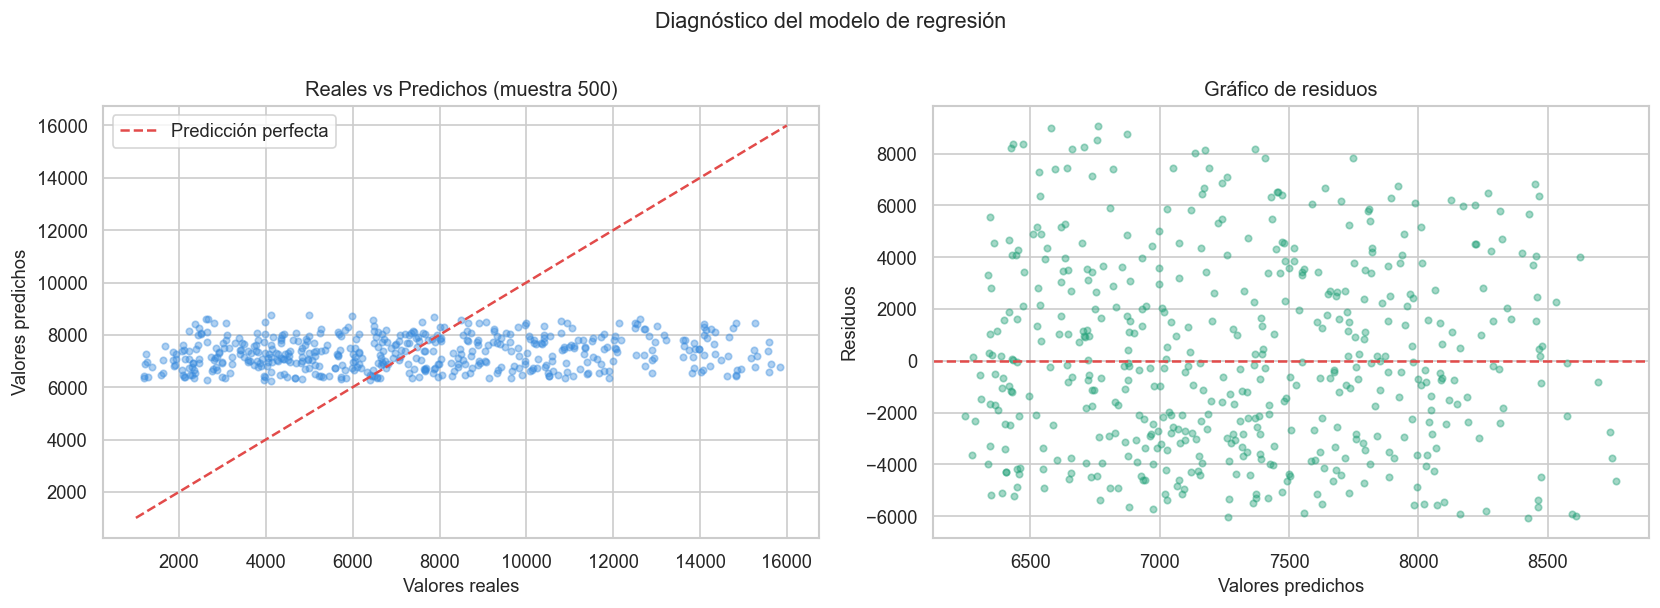

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_test_sample  = np.array(y_test)[sample_idx]
y_pred_sample  = y_pred[sample_idx]

axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.4, s=15, color="#378ADD")
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="#E24B4A", linewidth=1.5,
             linestyle="--", label="Predicción perfecta")
axes[0].set_xlabel("Valores reales", fontsize=11)
axes[0].set_ylabel("Valores predichos", fontsize=11)
axes[0].set_title("Reales vs Predichos (muestra 500)", fontsize=12)
axes[0].legend()

residuos = np.array(y_test) - y_pred
axes[1].scatter(y_pred_sample, residuos[sample_idx],
                alpha=0.4, s=15, color="#1D9E75")
axes[1].axhline(0, color="#E24B4A", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Valores predichos", fontsize=11)
axes[1].set_ylabel("Residuos", fontsize=11)
axes[1].set_title("Gráfico de residuos", fontsize=12)

plt.suptitle("Diagnóstico del modelo de regresión", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
X_sm = sm.add_constant(df["co2_emission"])
modelo_sm = sm.OLS(df["energy_consumption"], X_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:     energy_consumption   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     1111.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          6.33e-240
Time:                        12:59:56   Log-Likelihood:            -3.5146e+05
No. Observations:               36540   AIC:                         7.029e+05
Df Residuals:                   36538   BIC:                         7.029e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         6088.9823     40.914    148.824   

In [7]:
resultados_region = []

for region in sorted(df["region"].unique()):
    subset = df[df["region"] == region]
    X_r = subset[["co2_emission"]]
    y_r = subset["energy_consumption"]
    m_r = LinearRegression().fit(X_r, y_r)
    r2_r = r2_score(y_r, m_r.predict(X_r))
    r_pearson, p_r = stats.pearsonr(subset["co2_emission"],
                                     subset["energy_consumption"])
    resultados_region.append({
        "region"       : region,
        "r_pearson"    : round(r_pearson, 3),
        "R²"           : round(r2_r, 4),
        "coef"         : round(m_r.coef_[0], 4),
        "p_valor"      : round(p_r, 4),
        "significativa": "✅" if p_r < 0.05 else "❌",
        "n"            : len(subset)
    })

df_reg_region = pd.DataFrame(resultados_region)
display(df_reg_region)

,region,r_pearson,R²,coef,p_valor,significativa,n
0,América,0.164,0.0269,2.5562,0.0,✅,7308
1,Asia-Pacífico,0.160,0.0257,2.5553,0.0,✅,9135
2,Europa,0.181,0.0326,2.8425,0.0,✅,18270
3,África,0.172,0.0297,2.7063,0.0,✅,1827


In [8]:
resultados_pais = []

for pais in sorted(df["country"].unique()):
    subset = df[df["country"] == pais]
    X_p = subset[["co2_emission"]]
    y_p = subset["energy_consumption"]
    m_p = LinearRegression().fit(X_p, y_p)
    r2_p = r2_score(y_p, m_p.predict(X_p))
    r_p, p_p = stats.pearsonr(subset["co2_emission"],
                               subset["energy_consumption"])
    resultados_pais.append({
        "country"      : pais,
        "region"       : df[df["country"]==pais]["region"].iloc[0],
        "r_pearson"    : round(r_p, 3),
        "R²"           : round(r2_p, 4),
        "coef"         : round(m_p.coef_[0], 4),
        "significativa": "✅" if p_p < 0.05 else "❌"
    })

df_reg_pais = (pd.DataFrame(resultados_pais)
               .sort_values("r_pearson", ascending=False))
display(df_reg_pais)

,country,region,r_pearson,R²,coef,significativa
12,Norway,Europa,0.205,0.0422,3.2576,✅
16,Sweden,Europa,0.205,0.0418,3.3577,✅
8,Italy,Europa,0.203,0.0412,3.2236,✅
6,India,Asia-Pacífico,0.201,0.0403,3.2600,✅
13,Poland,Europa,0.189,0.0356,2.9778,✅
17,Turkey,Europa,0.181,0.0328,2.8678,✅
5,Germany,Europa,0.173,0.0299,2.7391,✅
11,Netherlands,Europa,0.172,0.0295,2.7174,✅
18,United Kingdom,Europa,0.172,0.0296,2.6480,✅
14,South Africa,África,0.172,0.0297,2.7063,✅


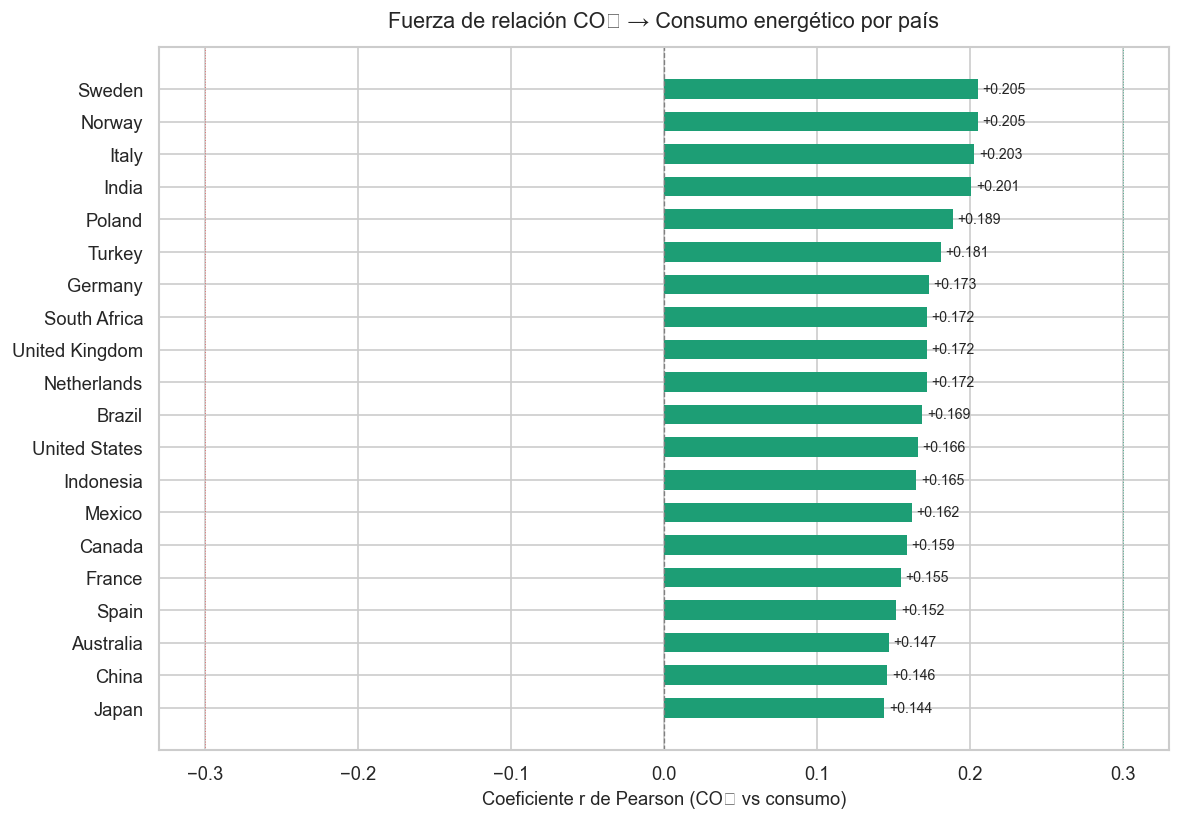

In [9]:
df_plot = df_reg_pais.sort_values("r_pearson", ascending=True)
colores = ["#1D9E75" if v > 0 else "#E24B4A" for v in df_plot["r_pearson"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_plot["country"], df_plot["r_pearson"],
               color=colores, edgecolor="none", height=0.6)
ax.axvline(0,    color="gray",    linewidth=0.8, linestyle="--")
ax.axvline(0.3,  color="#1D9E75", linewidth=0.6, linestyle=":", alpha=0.7)
ax.axvline(-0.3, color="#E24B4A", linewidth=0.6, linestyle=":", alpha=0.7)
ax.set_xlabel("Coeficiente r de Pearson (CO₂ vs consumo)", fontsize=11)
ax.set_title("Fuerza de relación CO₂ → Consumo energético por país", fontsize=13, pad=12)
for bar, val in zip(bars, df_plot["r_pearson"]):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8.5)
plt.tight_layout()
plt.show()

In [10]:
print("=" * 55)
print("BREAKPOINT — RESULTADOS CLAVE PARA VALIDAR")
print("=" * 55)

r_global, p_global = stats.pearsonr(df["co2_emission"],
                                     df["energy_consumption"])
print(f"\n  r global CO₂ vs consumo : {r_global:.4f}")
print(f"  p-valor                 : {p_global:.2e}")
print(f"  R² modelo global        : {r2:.4f}")
print(f"  RMSE modelo             : {rmse:.2f}")
print(f"  MAE modelo              : {mae:.2f}")

print(f"\n  R² por región:")
for _, row in df_reg_region.iterrows():
    print(f"    {row['region']:<20} r={row['r_pearson']:+.3f}  R²={row['R²']:.4f}  {row['significativa']}")

print(f"\n  Top 3 países mayor correlación CO₂-consumo:")
top3 = df_reg_pais.nlargest(3, "r_pearson")
for _, row in top3.iterrows():
    print(f"    {row['country']:<20} r={row['r_pearson']:+.3f}  {row['significativa']}")

print(f"\n  Bottom 3 países menor correlación:")
bot3 = df_reg_pais.nsmallest(3, "r_pearson")
for _, row in bot3.iterrows():
    print(f"    {row['country']:<20} r={row['r_pearson']:+.3f}  {row['significativa']}")

BREAKPOINT — RESULTADOS CLAVE PARA VALIDAR

  r global CO₂ vs consumo : 0.1718
  p-valor                 : 6.33e-240
  R² modelo global        : 0.0306
  RMSE modelo             : 3652.81
  MAE modelo              : 3080.24

  R² por región:
    América              r=+0.164  R²=0.0269  ✅
    Asia-Pacífico        r=+0.160  R²=0.0257  ✅
    Europa               r=+0.181  R²=0.0326  ✅
    África               r=+0.172  R²=0.0297  ✅

  Top 3 países mayor correlación CO₂-consumo:
    Norway               r=+0.205  ✅
    Sweden               r=+0.205  ✅
    Italy                r=+0.203  ✅

  Bottom 3 países menor correlación:
    Japan                r=+0.144  ✅
    China                r=+0.146  ✅
    Australia            r=+0.147  ✅


## 🔍 Insights finales — Regresión CO₂ vs Consumo energético

### Sobre la correlación global
- El coeficiente r = **0.1718** confirma una correlación positiva débil
  pero estadísticamente significativa (p = 6.33e-240 ≈ 0.0000).
- Con un p-valor tan extremadamente pequeño y 36,540 observaciones,
  la relación existe matemáticamente — pero su magnitud es pequeña.
- El **R² = 0.0306** es el dato más revelador: el modelo lineal simple
  solo explica el **3.06% de la varianza** del consumo energético.
  El 96.94% restante no lo explica esta variable por sí sola.

### Sobre la calidad del modelo
- El **RMSE = 3,652.81** y **MAE = 3,080.24** indican que en promedio
  el modelo se equivoca en ±3,080 unidades al predecir el consumo —
  sobre un rango total de 1,002 a 15,998, eso es un error considerable.
- Conclusión: un modelo de regresión lineal simple con CO₂ como única
  variable **no es suficiente** para predecir el consumo energético.
  En datos reales se requeriría un modelo multivariable.

### Sobre el análisis por región
- Las 4 regiones muestran correlaciones casi idénticas entre sí:
  Europa r = 0.181, África r = 0.172, América r = 0.164,
  Asia-Pacífico r = 0.160.
- La uniformidad entre regiones es otra evidencia clara del origen
  sintético del dataset — en datos reales esperaríamos diferencias
  regionales más marcadas.
- Todas las regiones son estadísticamente significativas (✅),
  pero con R² entre 0.026 y 0.033 — poder explicativo muy bajo en todas.

### Sobre el análisis por país
- Todos los 20 países muestran correlación **positiva** con el mismo
  signo — otro indicador de que el dato fue generado con un patrón
  uniforme global.
- El rango entre el país mayor (Norway/Sweden r = 0.205) y el menor
  (Japan r = 0.144) es de apenas 0.061 puntos — diferencia mínima
  que no tiene relevancia práctica.
- En datos reales esperaríamos que países con economías intensivas
  en manufactura (China, India) mostraran correlaciones mucho más
  fuertes que países con economías de servicios.

### Conclusión metodológica del proyecto
| Métrica | Valor real | Interpretación |
|---|---|---|
| r global | 0.1718 | Correlación débil positiva |
| R² global | 0.0306 | Modelo explica solo el 3% |
| MAE | 3,080.24 | Error promedio alto |
| RMSE | 3,652.81 | Sensible a errores grandes |
| Regiones significativas | 4 de 4 | Significancia estadística ✅ |
| Países significativos | 20 de 20 | Muestra grande compensa r bajo |

**El valor real de este proyecto no está en la magnitud de las
correlaciones sino en la correcta aplicación del proceso completo:
limpieza → exploración → visualización → estadística → regresión.
Ese flujo es 100% válido y replicable sobre cualquier dataset real.**

In [11]:
df_reg_pais.to_csv("../data/regresion_por_pais.csv", index=False)
df_reg_region.to_csv("../data/regresion_por_region.csv", index=False)

resumen_modelo = pd.DataFrame([{
    "r_global"  : round(r_global, 4),
    "R2_modelo" : round(r2, 4),
    "MAE"       : round(mae, 2),
    "RMSE"      : round(rmse, 2),
    "coeficiente": round(modelo.coef_[0], 4),
    "intercepto": round(modelo.intercept_, 2)
}])
resumen_modelo.to_csv("../data/resumen_modelo.csv", index=False)

print("✅ Archivos guardados:")
print("   data/regresion_por_pais.csv")
print("   data/regresion_por_region.csv")
print("   data/resumen_modelo.csv")

✅ Archivos guardados:
   data/regresion_por_pais.csv
   data/regresion_por_region.csv
   data/resumen_modelo.csv
